In [26]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.table import Table
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    
from utils import get_catalog_columns
from utils import get_shear_correlation

# 0. Load Files

In [27]:
datadir_root = '/scratch/gpfs/dy9683/'
datadir = os.path.join(datadir_root, 'matched_catalogs')

datadir_combined = os.path.join(datadir, "hsc_des_decade_combined_lensing_match_1.csv")
datadir_combined_with_duplicates = os.path.join(datadir, "hsc_des_decade_combined_with_duplicates_lensing_match_1.csv")

In [28]:
combined_catalog = pd.read_csv(datadir_combined)
combined_with_duplicates_catalog = pd.read_csv(datadir_combined_with_duplicates)

In [29]:
# look at redshifts and split into 3 redshift bins
# plot xi_+/- for these three 3 redshift bins
# compare to other signals

# 1. Split combined signal into 3 $z$ bins

In [30]:
# 0.1 < z < 0.5
# 0.5 < z < 1.5 
# z > 1.5

mask_first_z_bin = (combined_with_duplicates_catalog['Z_BEST'] >= 0.1) & (combined_with_duplicates_catalog['Z_BEST'] < 0.5)
mask_second_z_bin = (combined_with_duplicates_catalog['Z_BEST'] >= 0.5) & (combined_with_duplicates_catalog['Z_BEST'] < 1.5)
mask_third_z_bin = combined_with_duplicates_catalog['Z_BEST'] >= 1.5

combined_with_duplicates_first_z_bin_catalog = combined_with_duplicates_catalog[mask_first_z_bin]
combined_with_duplicates_second_z_bin_catalog = combined_with_duplicates_catalog[mask_second_z_bin]
combined_with_duplicates_third_z_bin_catalog = combined_with_duplicates_catalog[mask_third_z_bin]

In [31]:
ra_combined_with_duplicates_first_z_bin, dec_combined_with_duplicates_first_z_bin, g1_combined_with_duplicates_first_z_bin, g2_combined_with_duplicates_first_z_bin, z_combined_with_duplicates_first_z_bin = get_catalog_columns(combined_with_duplicates_first_z_bin_catalog)

In [32]:
ra_combined_with_duplicates_second_z_bin, dec_combined_with_duplicates_second_z_bin, g1_combined_with_duplicates_second_z_bin, g2_combined_with_duplicates_second_z_bin, z_combined_with_duplicates_second_z_bin = get_catalog_columns(combined_with_duplicates_second_z_bin_catalog)

In [33]:
ra_combined_with_duplicates_third_z_bin, dec_combined_with_duplicates_third_z_bin, g1_combined_with_duplicates_third_z_bin, g2_combined_with_duplicates_third_z_bin, z_combined_with_duplicates_third_z_bin = get_catalog_columns(combined_with_duplicates_third_z_bin_catalog)

In [43]:
combined_with_duplicates_first_z_bin_catalog_hsc = combined_with_duplicates_first_z_bin_catalog[combined_with_duplicates_first_z_bin_catalog['catalog'] == "hsc"]
combined_with_duplicates_second_z_bin_catalog_hsc = combined_with_duplicates_second_z_bin_catalog[combined_with_duplicates_second_z_bin_catalog['catalog'] == "hsc"]
combined_with_duplicates_third_z_bin_catalog_hsc = combined_with_duplicates_third_z_bin_catalog[combined_with_duplicates_third_z_bin_catalog['catalog'] == "hsc"]

In [57]:
print(fr"In 0.1 < z < 0.5: {len(combined_with_duplicates_first_z_bin_catalog_hsc):,} galaxies from HSC, {len(combined_with_duplicates_first_z_bin_catalog_des):,} galaxies from DES, {len(combined_with_duplicates_first_z_bin_catalog_decade):,} galaxies from DECADE")

print(fr"In 0.5 < z < 1.5: {len(combined_with_duplicates_second_z_bin_catalog_hsc):,} galaxies from HSC, {len(combined_with_duplicates_second_z_bin_catalog_des):,} galaxies from DES, {len(combined_with_duplicates_second_z_bin_catalog_decade):,} galaxies from DECADE")

print(fr"In       z > 1.5: {len(combined_with_duplicates_third_z_bin_catalog_hsc):,} galaxies from HSC, {len(combined_with_duplicates_third_z_bin_catalog_des):,} galaxies from DES, {len(combined_with_duplicates_third_z_bin_catalog_decade):,} galaxies from DECADE")



In 0.1 < z < 0.5: 287,241 galaxies from HSC, 1,337,641 galaxies from DES, 5,358,714 galaxies from DECADE
In 0.5 < z < 1.5: 996,992 galaxies from HSC, 1,328,114 galaxies from DES, 4,198,341 galaxies from DECADE
In       z > 1.5: 43,380 galaxies from HSC, 67,973 galaxies from DES, 185,587 galaxies from DECADE


In [44]:
combined_with_duplicates_first_z_bin_catalog_des = combined_with_duplicates_first_z_bin_catalog[combined_with_duplicates_first_z_bin_catalog['catalog'] == "des"]
combined_with_duplicates_second_z_bin_catalog_des = combined_with_duplicates_second_z_bin_catalog[combined_with_duplicates_second_z_bin_catalog['catalog'] == "des"]
combined_with_duplicates_third_z_bin_catalog_des = combined_with_duplicates_third_z_bin_catalog[combined_with_duplicates_third_z_bin_catalog['catalog'] == "des"]

In [45]:
combined_with_duplicates_first_z_bin_catalog_decade = combined_with_duplicates_first_z_bin_catalog[combined_with_duplicates_first_z_bin_catalog['catalog'] == "decade"]
combined_with_duplicates_second_z_bin_catalog_decade = combined_with_duplicates_second_z_bin_catalog[combined_with_duplicates_second_z_bin_catalog['catalog'] == "decade"]
combined_with_duplicates_third_z_bin_catalog_decade = combined_with_duplicates_third_z_bin_catalog[combined_with_duplicates_third_z_bin_catalog['catalog'] == "decade"]

# 2. Treecorr

In [34]:
datasets = {
    'combined_with_duplicates_first_z_bin': {'ra': ra_combined_with_duplicates_first_z_bin, 'dec': dec_combined_with_duplicates_first_z_bin, 
            'g1': g1_combined_with_duplicates_first_z_bin, 'g2': g2_combined_with_duplicates_first_z_bin},
    'combined_with_duplicates_second_z_bin': {'ra': ra_combined_with_duplicates_second_z_bin, 'dec': dec_combined_with_duplicates_second_z_bin, 
            'g1': g1_combined_with_duplicates_second_z_bin, 'g2': g2_combined_with_duplicates_second_z_bin},
    'combined_with_duplicates_third_z_bin': {'ra': ra_combined_with_duplicates_third_z_bin, 'dec': dec_combined_with_duplicates_third_z_bin, 
            'g1': g1_combined_with_duplicates_third_z_bin, 'g2': g2_combined_with_duplicates_third_z_bin}
}

In [35]:
results = {}
for name, data in datasets.items():
    results[name] = get_shear_correlation(
        ra=data['ra'], 
        dec=data['dec'], 
        g1=data['g1'], 
        g2=data['g2'])

In [36]:
for cat_name, data in results.items():
    globals()[f"xip_{cat_name}"] = data['xip']
    globals()[f"xim_{cat_name}"] = data['xim']
    globals()[f"r_{cat_name}"] = data['r']
    globals()[f"sig_xip_{cat_name}"] = data['sig_xip']
    globals()[f"sig_xim_{cat_name}"] = data['sig_xim']

# 3. Plots

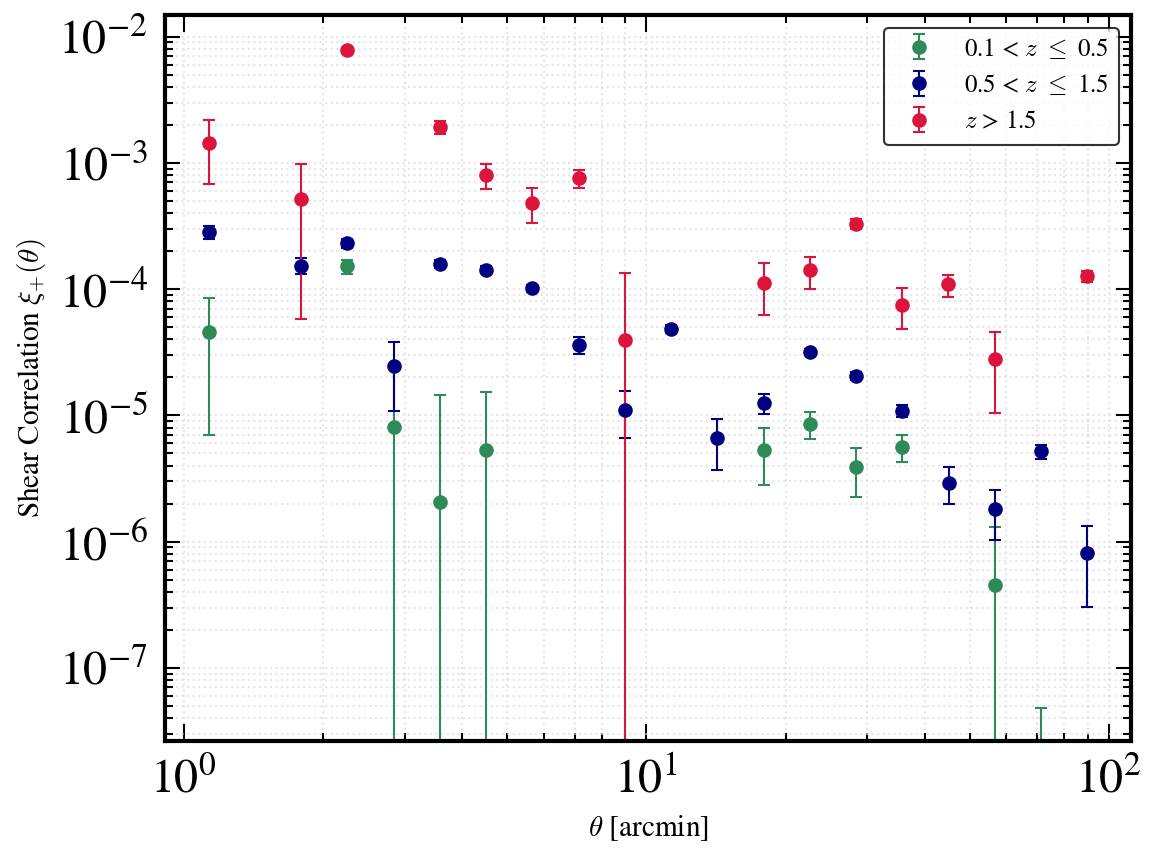

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_combined_with_duplicates_first_z_bin, xip_combined_with_duplicates_first_z_bin, yerr=sig_xip_combined_with_duplicates_first_z_bin, label=r'0.1 < $z$ $\leq$ 0.5', color='seagreen', capsize=3, fmt = "o")
ax.errorbar(r_combined_with_duplicates_second_z_bin, xip_combined_with_duplicates_second_z_bin, yerr=sig_xip_combined_with_duplicates_second_z_bin, label=r'0.5 < $z$ $\leq$ 1.5', color='navy', capsize=3, fmt = "o")
ax.errorbar(r_combined_with_duplicates_third_z_bin, xip_combined_with_duplicates_third_z_bin, yerr=sig_xip_combined_with_duplicates_third_z_bin, label=r'$z$ > 1.5', color='crimson', capsize=3, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
f